# UMAP — Saber 11

Este notebook aplica UMAP sobre las 19 variables de contexto (excluidas `punt_global` y
`cole_mcpio_ubicacion`) con **rank encoding por columna** como preprocesamiento.

---

## Decisiones de preprocesamiento

| # | Decisión | Elección | Razón |
|---|---|---|---|
| 1 | Excluir `punt_global` | Sí | Es el target; incluirlo sesgaría la geometría hacia el rendimiento |
| 2 | Excluir `cole_mcpio_ubicacion` | Sí | 1 081 valores únicos, sin codificación ordinal con sentido semántico |
| 3 | Encoding | Rank percentil por columna | Evita asumir distancias iguales entre niveles; más robusto que ordinal para SVD posterior; no infla dimensiones como OHE |
| 4 | Imputación | Mediana de ranks (0.5 = percentil 50) | Robusta para variables ordinales sesgadas |
| 5 | Escalado | StandardScaler post-rank | Los ranks ya son uniformes, pero escalar asegura que ninguna variable domine |
| 6 | Muestreo | 10 000 Urbano + 10 000 Rural (igual que nb 05) | Visualización balanceada; el desbalance real (87/13) se analiza por separado |

## 0. Dependencias

In [ ]:
#%pip install -q umap-learn kagglehub pandas scikit-learn matplotlib seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from scipy.stats import rankdata
from sklearn.preprocessing import StandardScaler
import umap
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)

SEED = 42
print('✔  Dependencias cargadas')

/Users/jacobo/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✔  Dependencias cargadas


## 1. Carga

Misma fuente que los notebooks anteriores: `v2_datos_limpios.csv` en Kaggle.

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'jacoboayala/datos-icfes-11',
    'v2_datos_limpios.csv',
    pandas_kwargs={'sep': ';', 'low_memory': False}
)
print(f'Filas: {len(df):,}  |  Columnas: {df.shape[1]}')
print(df['cole_area_ubicacion'].value_counts())

Filas: 4,821,037  |  Columnas: 28
cole_area_ubicacion
Urbano    4185434
Rural      635603
Name: count, dtype: int64


## 2. Muestreo balanceado

In [3]:
N_POR_DOMINIO = 10_000

df_sample = (
    df.groupby('cole_area_ubicacion', group_keys=False)
      .apply(lambda g: g.sample(n=min(N_POR_DOMINIO, len(g)), random_state=SEED))
      .reset_index(drop=True)
)

print(f'Muestra balanceada: {len(df_sample):,} filas')
print(df_sample['cole_area_ubicacion'].value_counts())

Muestra balanceada: 20,000 filas
cole_area_ubicacion
Rural     10000
Urbano    10000
Name: count, dtype: int64


## 3. Definición de features

Se excluyen:
- `punt_global` — target, su inclusión crearía una geometría dominada por rendimiento
- `cole_mcpio_ubicacion` — 1 081 valores únicos sin orden semántico útil

Se derivan:
- `estu_edad` — a partir de `estu_fechanacimiento` y `anio`

In [4]:
df_sample = df_sample.copy()
df_sample['_fnac'] = pd.to_datetime(
    df_sample['estu_fechanacimiento'],
    dayfirst=True,
    errors='coerce'
)
df_sample['estu_edad'] = df_sample['anio'] - df_sample['_fnac'].dt.year
df_sample = df_sample.drop(columns=['_fnac'])

# Edades fuera de rango → NaN (se imputan en sección 5)
mask_invalida = (df_sample['estu_edad'] < 13) | (df_sample['estu_edad'] > 35)
df_sample.loc[mask_invalida, 'estu_edad'] = np.nan
print(f'Edades fuera de [13, 35]: {mask_invalida.sum():,} → NaN')
print(df_sample['estu_edad'].describe().round(1))

Edades fuera de [13, 35]: 193 → NaN
count    19787.0
mean        17.5
std          2.0
min         13.0
25%         17.0
50%         17.0
75%         18.0
max         35.0
Name: estu_edad, dtype: float64


In [5]:
# Columnas de metadatos (no entran al modelo)
META_COLS = ['cole_area_ubicacion', 'cole_mcpio_ubicacion', 'cole_depto_ubicacion']

# 19 features para UMAP
# Se excluye punt_global (target) y cole_mcpio_ubicacion (alta cardinalidad sin orden)
UMAP_FEATURES = [
    # Familia
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_cuartoshogar',
    'fami_personashogar',
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'fami_tieneserviciotv',
    # Estudiante
    'estu_genero',
    'estu_grado',
    'estu_edad',
    # Colegio
    'cole_naturaleza',
    'cole_bilingue',
    'cole_jornada',
    'cole_genero',
    'cole_calendario',
    # Temporal
    'anio',
]

missing = [c for c in UMAP_FEATURES if c not in df_sample.columns]
print(f'Features faltantes: {missing}')
print(f'Total features: {len(UMAP_FEATURES)}')

Features faltantes: []
Total features: 19


## 4. Encoding ordinal semántico

Convertimos las columnas categóricas a enteros con el **mismo orden semántico que en nb 05**,
antes de aplicar el rank. El orden semántico importa porque preserva la monotonía del ranking:
`Estrato 1 < Estrato 2 < ... < Estrato 6` debe reflejarse en la posición del rank.

In [6]:
import unicodedata

def strip_accents(s):
    if pd.isna(s):
        return s
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode('ascii').strip().title()

SI_NO = {
    'fami_tieneinternet':   {'No': 0, 'Si': 1},
    'fami_tienecomputador': {'No': 0, 'Si': 1},
    'fami_tieneautomovil':  {'No': 0, 'Si': 1},
    'fami_tienelavadora':   {'No': 0, 'Si': 1},
    'fami_tieneserviciotv': {'No': 0, 'Si': 1},
    'cole_bilingue':        {'N': 0, 'S': 1},
}

MAP_ESTRATO   = {'Sin Estrato': 0, 'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
                 'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6}

MAP_EDUCACION = {
    'Ninguno': 0, 'Primaria Incompleta': 1, 'Primaria Completa': 2,
    'Secundaria (Bachillerato) Incompleta': 3, 'Secundaria (Bachillerato) Completa': 4,
    'Tecnica O Tecnologica Incompleta': 5, 'Tecnica O Tecnologica Completa': 6,
    'Educacion Profesional Incompleta': 7, 'Educacion Profesional Completa': 8,
    'Postgrado': 9, 'No Sabe': np.nan, 'No Aplica': np.nan,
}

MAP_CUARTOS   = {'Ninguno': 0, 'Uno': 1, 'Dos': 2, 'Tres': 3, 'Cuatro': 4,
                 'Cinco': 5, 'Seis': 6, 'Siete': 7, 'Ocho': 8, 'Nueve': 9,
                 'Seis O Mas': 6, 'Diez O Mas': 10}

MAP_PERSONAS  = {'Una': 1, 'Dos': 2, 'Tres': 3, 'Cuatro': 4, 'Cinco': 5,
                 'Seis': 6, 'Siete': 7, 'Ocho': 8, 'Nueve': 9, 'Diez': 10,
                 'Once': 11, 'Doce O Mas': 12,
                 '1 A 2': 1.5, '3 A 4': 3.5, '5 A 6': 5.5, '7 A 8': 7.5, '9 O Mas': 9}

MAP_JORNADA   = {'Noche': 0, 'Fin De Semana': 1, 'Sabatina': 1,
                 'Tarde': 2, 'Manana': 3, 'Unica': 4, 'Unica': 4, 'Completa': 5}

MAP_GENERO_COLE = {'Mixto': 0, 'Femenino': 1, 'Masculino': 2}
MAP_GENERO_ESTU = {'M': 0, 'F': 1}
MAP_NATURALEZA  = {'Oficial': 0, 'No Oficial': 1}
MAP_CALENDARIO  = {'A': 0, 'B': 1, 'Otro': np.nan}

print('Mapeos definidos.')

Mapeos definidos.


In [7]:
df_enc = df_sample[META_COLS + UMAP_FEATURES].copy()

# Normalizar tildes y mayúsculas en columnas string
COLS_STR = [c for c in UMAP_FEATURES if df_enc[c].dtype == object]
for col in COLS_STR:
    df_enc[col] = df_enc[col].map(strip_accents)

# Binarias
for col, mapping in SI_NO.items():
    df_enc[col] = df_enc[col].map(mapping)

# Ordinales
df_enc['fami_estratovivienda'] = df_enc['fami_estratovivienda'].map(MAP_ESTRATO)
df_enc['fami_educacionmadre']  = df_enc['fami_educacionmadre'].map(MAP_EDUCACION)
df_enc['fami_educacionpadre']  = df_enc['fami_educacionpadre'].map(MAP_EDUCACION)
df_enc['fami_cuartoshogar']    = df_enc['fami_cuartoshogar'].map(MAP_CUARTOS)
df_enc['fami_personashogar']   = df_enc['fami_personashogar'].map(MAP_PERSONAS)
df_enc['estu_genero']          = df_enc['estu_genero'].map(MAP_GENERO_ESTU)
df_enc['cole_naturaleza']      = df_enc['cole_naturaleza'].map(MAP_NATURALEZA)
df_enc['cole_jornada']         = df_enc['cole_jornada'].map(MAP_JORNADA)
df_enc['cole_genero']          = df_enc['cole_genero'].map(MAP_GENERO_COLE)
df_enc['cole_calendario']      = df_enc['cole_calendario'].map(MAP_CALENDARIO)

# Verificar que no queden strings
remaining_str = df_enc[UMAP_FEATURES].select_dtypes(include='object').columns.tolist()
print(f'Columnas string sin mapear: {remaining_str}')

print('\nNulos por columna:')
nulos = df_enc[UMAP_FEATURES].isnull().sum()
print(nulos[nulos > 0])

Columnas string sin mapear: []

Nulos por columna:
fami_educacionmadre     342
fami_educacionpadre    1182
estu_edad               213
cole_calendario          73
dtype: int64


## 5. Rank encoding (percentil por columna)

Para cada columna transformamos los valores a su **rango percentil** en $[0, 1]$.

**¿Por qué rank en vez del ordinal directo?**

- El ordinal asume que la distancia entre `Estrato 1 → 2` es igual a `Estrato 5 → 6`,
  lo cual no es cierto socioeconomicamente.
- El rank es una transformación monotónica que preserva el orden pero no asume distancias
  uniformes — convierte la distribución marginal a uniforme.
- Para SVD (biplot) posterior: las flechas seguirán siendo interpretables porque el rank
  es monotónico; y la covarianza entre variables de distinta escala es más estable.
- Alternativa que no usamos: OHE — infla dimensiones de $p=19$ a $p \approx 100$, lo que
  destruye la interpretabilidad de las flechas del biplot.

Los nulos se imputan con **mediana de ranks = 0.5** antes de rankear.

In [9]:
# Imputar nulos con mediana antes del rank
medianas = df_enc[UMAP_FEATURES].median()
df_enc[UMAP_FEATURES] = df_enc[UMAP_FEATURES].fillna(medianas)
assert df_enc[UMAP_FEATURES].isnull().sum().sum() == 0, 'Aún hay nulos'

# Rank percentil (pct=True → valores en [0, 1])
# method='average': los empates reciben la media de sus rangos
df_rank = df_enc[UMAP_FEATURES].rank(pct=True, method='average')

print('Distribución de ranks (deben estar en [0, 1] con media ~0.5):')
print(df_rank.describe().round(3).loc[['min', 'mean', 'max']].to_string())

Distribución de ranks (deben estar en [0, 1] con media ~0.5):
      fami_estratovivienda  fami_educacionmadre  fami_educacionpadre  fami_cuartoshogar  fami_personashogar  fami_tieneinternet  fami_tienecomputador  fami_tieneautomovil  fami_tienelavadora  fami_tieneserviciotv  estu_genero  estu_grado  estu_edad  cole_naturaleza  cole_bilingue  cole_jornada  cole_genero  cole_calendario   anio
min                  0.020                0.013                0.022              0.026               0.001               0.236                 0.251                0.388               0.158                 0.169        0.228        0.45        0.0            0.412          0.487         0.020        0.488            0.487  0.050
mean                 0.500                0.500                0.500              0.500               0.500               0.500                 0.500                0.500               0.500                 0.500        0.500        0.50        0.5            0.500         

## 6. Escalado

Los ranks ya son uniformes en $[0, 1]$, pero StandardScaler los centra en 0 y los
pone a std 1 — paso necesario para que ninguna variable domine en UMAP ni en SVD.

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(df_rank.to_numpy())

print(f'Shape de X: {X.shape}  (observaciones × features)')
print(f'Media global: {X.mean():.4f}  (debe ser ~0)')
print(f'Std global:   {X.std():.4f}   (debe ser ~1)')

Shape de X: (20000, 19)  (observaciones × features)
Media global: -0.0000  (debe ser ~0)
Std global:   1.0000   (debe ser ~1)


## 7. UMAP

### Parámetros principales

| Parámetro | Valor | Justificación |
|---|---|---|
| `n_neighbors` | 30 | Balance entre estructura local y global; 15 es demasiado local para 20k puntos |
| `min_dist` | 0.1 | Compactación moderada; 0.0 agrupa demasiado, dificulta ver solapamiento Urbano/Rural |
| `n_components` | 2 | Visualización 2D para exploración inicial |
| `metric` | `euclidean` | Adecuado post-standardización de ranks |
| `random_state` | 42 | Reproducibilidad |

In [21]:
C=5

In [18]:
reducer = umap.UMAP(n_components=2, random_state=42)
Z = reducer.fit_transform(X)

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=C, random_state=42)
labels = kmeans.fit_predict(Z)

In [23]:
import numpy as np

loadings = {}
for c in range(C):
    Xc = X[labels == c]
    Xc_centered = Xc - Xc.mean(axis=0)
    
    U, S, Vt = np.linalg.svd(Xc_centered, full_matrices=False)
    
    # Loading matrix Bc = Vc / Sc^0.5 (top 2)
    Bc = Vt[:2, :].T / np.sqrt(S[:2])  # shape (P, 2)
    loadings[c] = Bc

In [24]:
from scipy.optimize import minimize

def objective(params, Bc, Zc):
    gamma, nu = params[0], params[1:]
    Bc_aligned = gamma * Bc + nu
    # Proyección local
    Zc_hat = (Xc_centered @ Bc_aligned)
    return np.linalg.norm(Zc_hat - Zc, 'fro')

aligned_loadings = {}
for c in range(C):
    Xc = X[labels == c]
    Zc = Z[labels == c]
    Xc_centered = Xc - Xc.mean(axis=0)
    Bc = loadings[c]
    
    x0 = [1.0, 0.0, 0.0]  # gamma, nu1, nu2
    result = minimize(objective, x0, args=(Bc, Zc), method='Nelder-Mead')
    gamma, nu = result.x[0], result.x[1:]
    
    aligned_loadings[c] = gamma * Bc + nu

In [29]:
feature_names = [f'f{i+1}' for i in range(X.shape[1])]

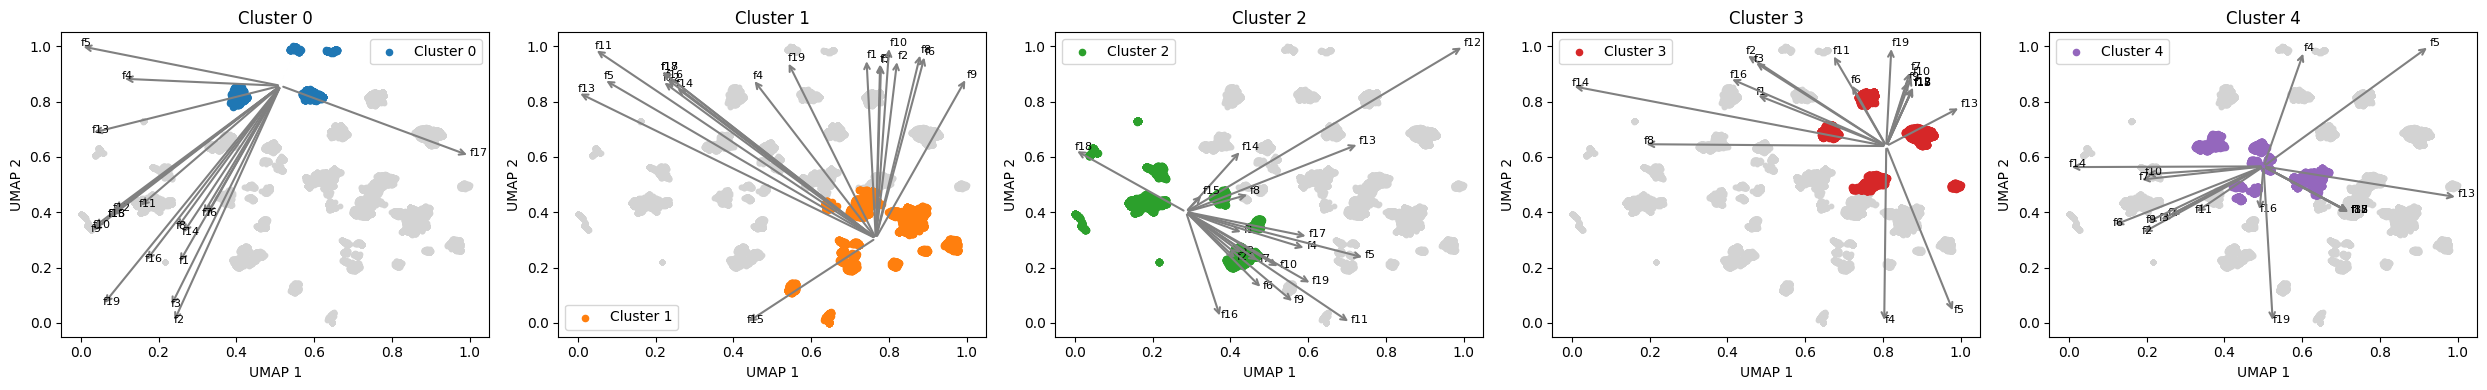

In [31]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

fig, axes = plt.subplots(1, C, figsize=(5*C, 4))

for c in range(C):
    ax = axes[c]
    
    # Puntos: todos en gris, cluster actual destacado
    ax.scatter(Z_norm[:, 0], Z_norm[:, 1], color='lightgray', s=10, zorder=1)
    mask = labels == c
    ax.scatter(Z_norm[mask, 0], Z_norm[mask, 1], 
               color=colors[c], label=f'Cluster {c}', s=20, zorder=2)
    
    # Centroide del cluster en espacio normalizado
    centro = Z_norm[mask].mean(axis=0)
    
    # Flechas solo del cluster c
    Bl = MinMaxScaler().fit_transform(aligned_loadings[c])
    for i, name in enumerate(feature_names):
        ax.annotate("", xy=(Bl[i, 0], Bl[i, 1]),
                    xytext=(centro[0], centro[1]),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
        ax.text(Bl[i, 0], Bl[i, 1], name, fontsize=8)
    
    ax.set_title(f'Cluster {c}')
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend()

plt.tight_layout()
plt.show()